# AI Lead Scoring & Sales Follow-up System

### Objective

Understand the raw EdTech lead dataset before preprocessing
and model development.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [6]:
df = pd.read_csv("../data/raw/Lead Scoring.csv")
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [7]:
df.shape

(9240, 37)

In [8]:
df.columns

Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

In [15]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [16]:
df.describe(include="object")

C:\Users\mohsi\AppData\Local\Temp\ipykernel_16552\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Prospect ID,Lead Origin,Lead Source,Do Not Email,Do Not Call,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,...,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
count,9240,9240,9204,9240,9240,9137,6779,7802,7033,6550,...,4473,9240,9240,6531,7820,5022,5022,9240,9240,9240
unique,9240,5,21,2,2,17,38,19,10,6,...,5,1,1,6,7,3,3,1,2,16
top,7927b2df-8bba-4d29-b9a2-b6e0beafe620,Landing Page Submission,Google,No,No,Email Opened,India,Select,Select,Unemployed,...,Might be,No,No,Select,Mumbai,02.Medium,02.Medium,No,No,Modified
freq,1,4886,2868,8506,9238,3437,6492,1942,5043,5600,...,1560,9240,9240,4146,3222,3839,2788,9240,6352,3407


In [17]:
df["Converted"].value_counts()

Converted
0    5679
1    3561
Name: count, dtype: int64

In [19]:
df["Converted"].value_counts(normalize=True)*100

Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64

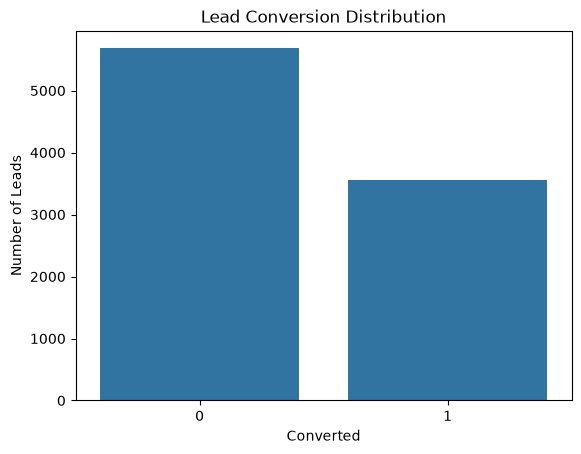

In [20]:
sns.countplot(data=df, x="Converted")
plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Leads")
plt.show()

## 3. Categorical Feature Exploration

In [21]:
categorical_columns = [
    "Lead Origin",
    "Lead Source",
    "Do Not Email",
    "Do Not Call",
    "Last Activity",
    "Country",
    "Specialization",
    "How did you hear about X Education",
    "What is your current occupation",
    "What matters most to you in choosing a course",
    "Lead Profile",
    "City",
    "Last Notable Activity"
]

In [22]:
for col in categorical_columns:
    print(f"\n{'='*80}")
    print(f"{col}")
    print(f"{'='*80}")
    print(df[col].value_counts(dropna=False).head(15))


Lead Origin
Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64

Lead Source
Lead Source
Google              2868
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Facebook              55
NaN                   36
bing                   6
google                 5
Click2call             4
Social Media           2
Live Chat              2
Press_Release          2
Name: count, dtype: int64

Do Not Email
Do Not Email
No     8506
Yes     734
Name: count, dtype: int64

Do Not Call
Do Not Call
No     9238
Yes       2
Name: count, dtype: int64

Last Activity
Last Activity
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                4

Let's Investigate the Marketing features

In [23]:
marketing_columns = [
    "Search",
    "Magazine",
    "Newspaper Article",
    "X Education Forums",
    "Newspaper",
    "Digital Advertisement",
    "Through Recommendations",
    "Receive More Updates About Our Courses",
    "Update me on Supply Chain Content",
    "Get updates on DM Content",
    "I agree to pay the amount through cheque",
    "A free copy of Mastering The Interview"
]

for col in marketing_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Search
Search
No     9226
Yes      14
Name: count, dtype: int64

Magazine
Magazine
No    9240
Name: count, dtype: int64

Newspaper Article
Newspaper Article
No     9238
Yes       2
Name: count, dtype: int64

X Education Forums
X Education Forums
No     9239
Yes       1
Name: count, dtype: int64

Newspaper
Newspaper
No     9239
Yes       1
Name: count, dtype: int64

Digital Advertisement
Digital Advertisement
No     9236
Yes       4
Name: count, dtype: int64

Through Recommendations
Through Recommendations
No     9233
Yes       7
Name: count, dtype: int64

Receive More Updates About Our Courses
Receive More Updates About Our Courses
No    9240
Name: count, dtype: int64

Update me on Supply Chain Content
Update me on Supply Chain Content
No    9240
Name: count, dtype: int64

Get updates on DM Content
Get updates on DM Content
No    9240
Name: count, dtype: int64

I agree to pay the amount through cheque
I agree to pay the amount through cheque
No    9240
Name: count, dtype: int64

A fre

## 4. Coversion Rate Analysis

In [38]:
lead_source_conversion = (
    df.groupby("Lead Source", dropna = False)["Converted"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
    )
lead_source_conversion

,count,mean
Lead Source,,
Live Chat,2,1.000000
NC_EDM,1,1.000000
WeLearn,1,1.000000
Welingak Website,142,0.985915
Reference,534,0.917603
NaN,36,0.805556
Click2call,4,0.750000
Social Media,2,0.500000
Google,2868,0.399930


In [39]:
lead_source_conversion["conversion_rate"] = (
    lead_source_conversion["mean"] * 100
)

lead_source_conversion

,count,mean,conversion_rate
Lead Source,,,
Live Chat,2,1.000000,100.000000
NC_EDM,1,1.000000,100.000000
WeLearn,1,1.000000,100.000000
Welingak Website,142,0.985915,98.591549
Reference,534,0.917603,91.760300
NaN,36,0.805556,80.555556
Click2call,4,0.750000,75.000000
Social Media,2,0.500000,50.000000
Google,2868,0.399930,39.993026


In [40]:
lead_origin_conversion = (
    df.groupby("Lead Origin", dropna = False)["Converted"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

lead_origin_conversion["conversion_rate"] = (lead_origin_conversion["mean"] * 100)

lead_origin_conversion

,count,mean,conversion_rate
Lead Origin,,,
Quick Add Form,1,1.000000,100.000000
Lead Add Form,718,0.924791,92.479109
Landing Page Submission,4886,0.361850,36.185018
API,3580,0.311453,31.145251
Lead Import,55,0.236364,23.636364


In [41]:
lead_source_conversion[lead_source_conversion["count"] >= 50]

,count,mean,conversion_rate
Lead Source,,,
Welingak Website,142,0.985915,98.591549
Reference,534,0.917603,91.760300
Google,2868,0.399930,39.993026
Organic Search,1154,0.377816,37.781629
Direct Traffic,2543,0.321667,32.166732
Olark Chat,1755,0.255271,25.527066
Referral Sites,125,0.248000,24.800000
Facebook,55,0.236364,23.636364


In [42]:
lead_source_conversion[
    lead_source_conversion["count"] >= 50
].sort_values("conversion_rate", ascending=False)

,count,mean,conversion_rate
Lead Source,,,
Welingak Website,142,0.985915,98.591549
Reference,534,0.917603,91.760300
Google,2868,0.399930,39.993026
Organic Search,1154,0.377816,37.781629
Direct Traffic,2543,0.321667,32.166732
Olark Chat,1755,0.255271,25.527066
Referral Sites,125,0.248000,24.800000
Facebook,55,0.236364,23.636364


In [43]:
def categorical_conversion_analysis(df, column, target="Converted", min_count=50):
    result = (
        df.groupby(column, dropna=False)[target]
        .agg(["count", "mean"])
        .rename(columns={"mean": "conversion_rate"})
    )
    
    result["conversion_rate"] *= 100
    
    return result.sort_values("conversion_rate", ascending=False)

In [44]:
lead_source_analysis = categorical_conversion_analysis(
    df,
    "Lead Source"
)

lead_source_analysis

,count,conversion_rate
Lead Source,,
Live Chat,2,100.000000
NC_EDM,1,100.000000
WeLearn,1,100.000000
Welingak Website,142,98.591549
Reference,534,91.760300
NaN,36,80.555556
Click2call,4,75.000000
Social Media,2,50.000000
Google,2868,39.993026


### Categorical features to be analyz

In [45]:
categorical_features_to_analyze = [
    "Do Not Email",
    "Country",
    "Specialization",
    "How did you hear about X Education",
    "What is your current occupation",
    "What matters most to you in choosing a course",
    "Lead Profile",
    "City"
]

In [50]:
for col in categorical_features_to_analyze:
    print(f"\n{'='*80}")
    print(col)
    print(f"{'='*80}")
    
    result = categorical_conversion_analysis(df, col)
    display(result[result["count"]>= 50])


Do Not Email


,count,conversion_rate
Do Not Email,,
No,8506,40.477310
Yes,734,16.076294



Country


,count,conversion_rate
Country,,
NaN,2461,43.722064
United Arab Emirates,53,37.735849
India,6492,36.983980
United States,69,26.086957



Specialization


...

,count,conversion_rate
What matters most to you in choosing a course,,
Better Career Prospects,6528,48.866422
NaN,2709,13.658176



Lead Profile


,count,conversion_rate
Lead Profile,,
Potential Lead,1613,78.549287
Select,4146,40.810420
Other Leads,487,36.960986
NaN,2709,13.658176
Student of SomeSchool,241,3.734440



City


,count,conversion_rate
City,,
Select,2249,49.044020
Thane & Outskirts,752,44.946809
Other Cities of Maharashtra,457,43.982495
Other Metro Cities,380,40.789474
Mumbai,3222,40.626940
Other Cities,686,40.233236
Tier II Cities,74,33.783784
NaN,1420,10.845070


## Categorical Feature Analysis — Key Findings

The categorical feature analysis was performed by comparing the number of leads and conversion rate across categories. The following observations were identified:

### Strong Predictive Candidates

- **Lead Origin:** Major differences in conversion rates were observed across lead origins. `Lead Add Form` showed a substantially higher historical conversion rate than `Landing Page Submission` and `API`.
- **Lead Source:** Conversion rates varied considerably across major lead sources. `Reference` and `Welingak Website` showed particularly high conversion rates, while `Olark Chat`, `Referral Sites`, and `Facebook` were considerably lower.
- **Do Not Email:** Leads with `Do Not Email = Yes` had a much lower conversion rate than leads who allowed email communication.
- **Occupation:** `Working Professional` showed a very high historical conversion rate compared with `Unemployed` and `Student`, making occupation a potentially strong predictive feature.
- **Specialization:** Conversion rates varied across specializations. Missing specialization information was associated with a substantially lower conversion rate.
- **Lead Profile:** Large differences were observed between profile categories, particularly `Potential Lead` and `Student of SomeSchool`. However, this feature requires further investigation for possible data leakage before it can be used for modeling.

### Missing-Value Patterns

A notable pattern was observed across several categorical variables. Missing values were consistently associated with substantially lower conversion rates.

This was observed in features such as:

- `Specialization`
- `How did you hear about X Education`
- `What is your current occupation`
- `What matters most to you in choosing a course`
- `Lead Profile`
- `City`

This suggests that missingness may itself contain predictive information. Therefore, missing categorical values should not automatically be replaced with the most frequent category. We will investigate an explicit `Unknown`/missing category during preprocessing.

### Data Quality Observations

- `Lead Source` contains inconsistent categories such as `Google` and `google`, which should be normalized during preprocessing.
- Several categorical variables contain the value `Select`, which appears to represent a non-selection rather than a genuine category. However, `Select` and actual `NaN` values showed different conversion behavior in several features, so they should not be combined automatically.
- `Do Not Call` contains almost no variation (`9,238` No vs `2` Yes) and is therefore a candidate for removal due to near-zero variance.
- Very rare categories showed extreme conversion rates, including 100% conversion in some cases. These rates are based on very small sample sizes and should not be interpreted as reliable business evidence.

### Current Feature Decisions

| Feature | Current Decision |
|---|---|
| Lead Origin | Keep |
| Lead Source | Keep + normalize categories |
| Do Not Email | Keep |
| Do Not Call | Drop |
| Country | Keep initially |
| Specialization | Keep + preserve missingness |
| How did you hear about X Education | Keep + investigate missingness |
| Occupation | Keep |
| What matters most to you in choosing a course | Keep initially / evaluate later |
| Lead Profile | Investigate for possible leakage |
| City | Keep initially / evaluate later |
| Last Activity | Investigate separately |
| Last Notable Activity | Investigate separately |

### Key Conclusion

Categorical analysis indicates that **lead acquisition channel, communication preference, occupation, specialization, and certain lead-profile characteristics are associated with historical conversion behavior**.

However, observed association does not necessarily imply causation. Final feature selection will be based on:

1. Predictive usefulness
2. Availability at prediction time
3. Data quality
4. Leakage risk
5. Model performance

Further analysis will be performed for numerical and binary features before finalizing the preprocessing and feature-engineering strategy.

## Numerical Feature Analysis

In [51]:
# Numerical Features
numerical_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Score"
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.0,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.0,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.0,55.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.0,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.0,20.0


In [ ]:
# Compare converted vs non converted leads 
# Mead Comparision
df.groupby("Converted")[numerical_features].mean().T

Converted,0,1
TotalVisits,3.329670,3.633632
Total Time Spent on Website,330.404473,738.546757
Page Views Per Visit,2.368453,2.353638
Asymmetrique Activity Score,14.123956,14.603774
Asymmetrique Profile Score,16.035003,16.850629


In [56]:
# Compare converted vs non converted leads 
# Median Comparision
df.groupby("Converted")[numerical_features].median().T

Converted,0,1
TotalVisits,3.0,3.0
Total Time Spent on Website,179.0,832.0
Page Views Per Visit,2.0,2.0
Asymmetrique Activity Score,14.0,15.0
Asymmetrique Profile Score,15.0,17.0


Distribution Visualization

In [59]:
core_numerical_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit"
]

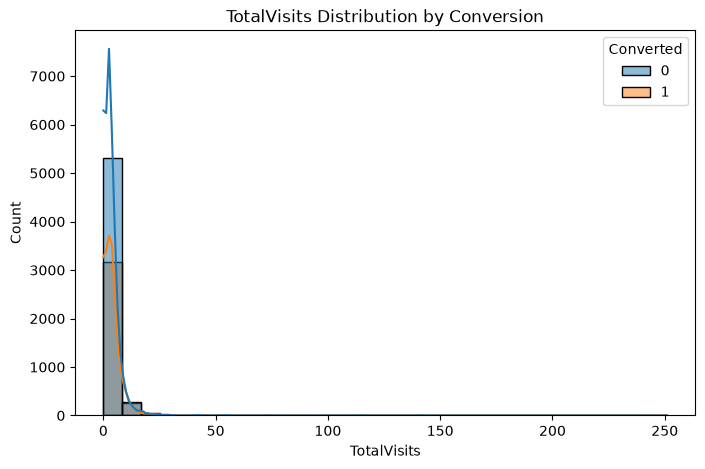

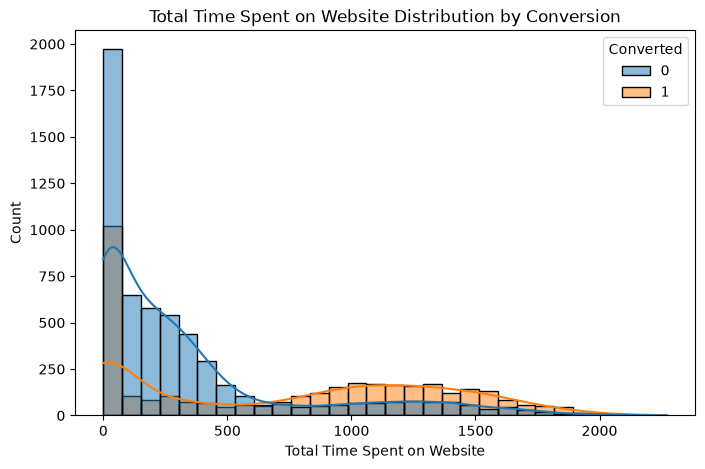

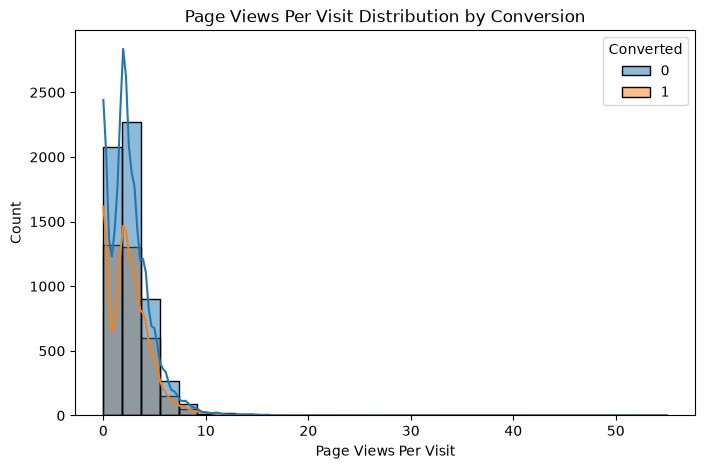

In [ ]:
Histogram

for col in core_numerical_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=col,
        hue="Converted",
        kde=True,
        bins=30
    )
    
    plt.title(f"{col} Distribution by Conversion")
    plt.show()

The Box Plot

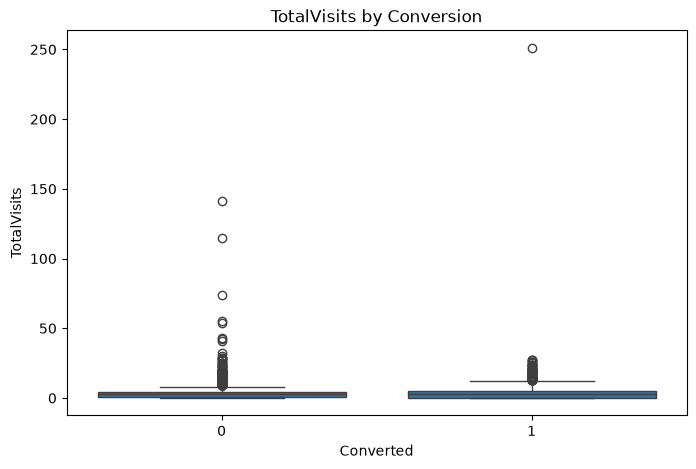

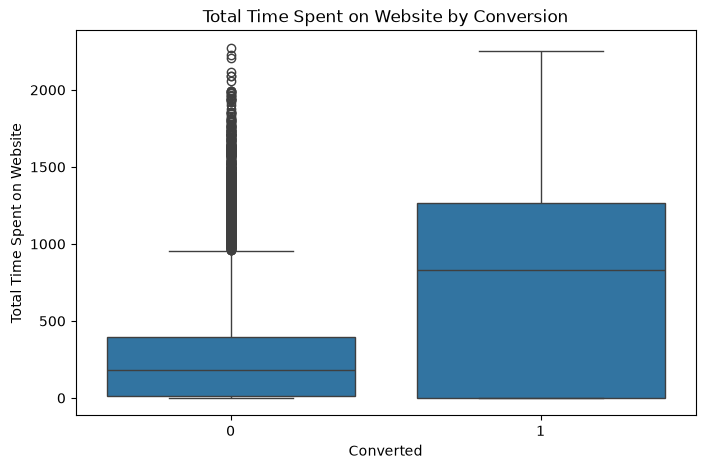

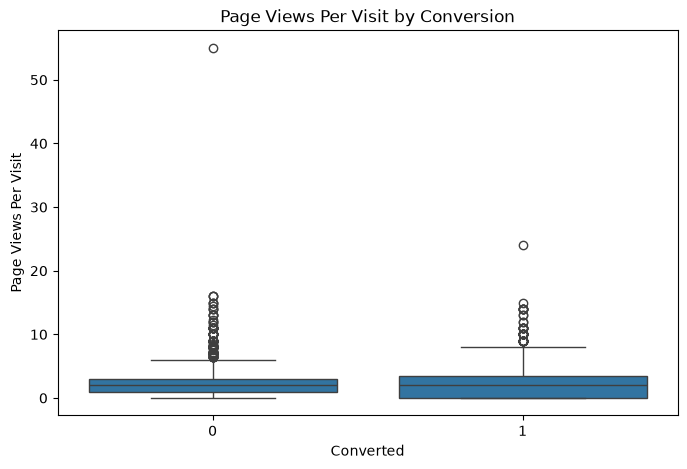

In [ ]:
# Box Plot

for col in core_numerical_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="Converted",
        y=col
    )
    
    plt.title(f"{col} by Conversion")
    plt.xlabel("Converted")
    plt.ylabel(col)
    plt.show()

In [63]:
#Missing Value Analysis

for col in ["TotalVisits", "Page Views Per Visit"]:
    print(f"\n{col}")
    
    result = (
        df.groupby(df[col].isna())["Converted"]
        .agg(["count", "mean"])
    )
    
    result["conversion_rate"] = result["mean"] * 100
    
    print(result)


TotalVisits
             count      mean  conversion_rate
TotalVisits                                  
False         9103  0.380204        38.020433
True           137  0.729927        72.992701

Page Views Per Visit
                      count      mean  conversion_rate
Page Views Per Visit                                  
False                  9103  0.380204        38.020433
True                    137  0.729927        72.992701


## Numerical Feature Analysis — Key Findings

The numerical features were analyzed using descriptive statistics, comparison of converted vs. non-converted leads, distribution plots, boxplots, and missing-value analysis.

### Key Findings

- **Total Time Spent on Website** showed the strongest relationship with conversion among the core numerical features. Converted leads had substantially higher mean and median website time than non-converted leads, indicating that website engagement is an important potential predictor of conversion.

- **TotalVisits** showed only a modest difference between converted and non-converted leads. The median number of visits was the same for both groups, although converted leads had a slightly higher mean. The feature also showed significant right skew and extreme values, so outliers will be investigated during preprocessing.

- **Page Views Per Visit** showed very similar mean and median values between converted and non-converted leads. Therefore, it appears to have relatively weak predictive signal compared with total website engagement time.

- **Asymmetrique Activity Score** and **Asymmetrique Profile Score** showed some differences between converted and non-converted leads. However, both features are available for only 5,022 of 9,240 leads. Their business meaning, generation process, prediction-time availability, and missing-value pattern require further investigation before they are included in the final model.

### Distribution and Outlier Observations

`TotalVisits` and `Page Views Per Visit` contain extreme values relative to their medians, indicating right-skewed distributions. These observations will not be removed automatically because high engagement may represent legitimate leads. Their impact will be evaluated during preprocessing and model development.

### Missing-Value Observations

Missing values in numerical features were examined separately to determine whether missingness itself is associated with conversion. This will inform the eventual missing-value treatment rather than automatically replacing missing values with a statistical summary such as the mean or median.

### Current Numerical Feature Decisions

| Feature | Current Decision |
|---|---|
| TotalVisits | Keep initially; investigate skew/outliers |
| Total Time Spent on Website | Strong candidate; keep |
| Page Views Per Visit | Keep initially; evaluate model usefulness |
| Asymmetrique Activity Score | Investigate before final decision |
| Asymmetrique Profile Score | Investigate before final decision |

### Key Conclusion

Website engagement, particularly **Total Time Spent on Website**, appears to be an important signal for lead conversion. However, final feature selection will be determined after completing the remaining EDA, checking prediction-time availability and leakage, and evaluating model performance.

## Binary Feature Analysis

Binary features represent lead preferences, marketing interactions, or communication choices.

For each feature, we will compare:
- Number of leads in each category
- Conversion rate
- Difference in conversion behavior

The goal is to identify whether these signals can help prioritize leads.

In [64]:
binary_features = [
    "Search",
    "Magazine",
    "Newspaper Article",
    "X Education Forums",
    "Newspaper",
    "Digital Advertisement",
    "Through Recommendations",
    "Receive More Updates About Our Courses",
    "Update me on Supply Chain Content",
    "Get updates on DM Content",
    "I agree to pay the amount through cheque",
    "A free copy of Mastering The Interview"
]

In [70]:

for col in binary_features:
    print(f"\n{'=' * 80}")
    print(col)
    print(f"{'=' * 80}")
    
    result = categorical_conversion_analysis(df, col)
    display(result)


Search


,count,conversion_rate
Search,,
No,9226,38.543247
Yes,14,35.714286



Magazine


,count,conversion_rate
Magazine,,
No,9240,38.538961



Newspaper Article


...

,count,conversion_rate
Get updates on DM Content,,
No,9240,38.538961



I agree to pay the amount through cheque


,count,conversion_rate
I agree to pay the amount through cheque,,
No,9240,38.538961



A free copy of Mastering The Interview


,count,conversion_rate
A free copy of Mastering The Interview,,
No,6352,39.845718
Yes,2888,35.664820


## Binary Feature Analysis — Key Findings

The binary features were evaluated by comparing category frequency and historical conversion rates.

### Key Findings

Most binary marketing and preference features showed extremely low variation. Several features contained zero or fewer than 10 positive observations, making their apparent conversion differences statistically unreliable and unlikely to provide meaningful predictive value.

Features such as `Magazine`, `Receive More Updates About Our Courses`, `Update me on Supply Chain Content`, `Get updates on DM Content`, and `I agree to pay the amount through cheque` contained no positive observations and therefore provide no useful discriminatory information.

Features including `Search`, `Newspaper Article`, `X Education Forums`, `Newspaper`, `Digital Advertisement`, and `Through Recommendations` contained very few positive observations. Their conversion rates should not be interpreted as reliable evidence because of the extremely small sample sizes.

`A free copy of Mastering The Interview` had sufficient variation but showed only a small difference in conversion rate between the two categories. It will be retained temporarily and evaluated during model development.

### Current Decisions

| Feature | Decision |
|---|---|
| Search | Drop |
| Magazine | Drop |
| Newspaper Article | Drop |
| X Education Forums | Drop |
| Newspaper | Drop |
| Digital Advertisement | Drop |
| Through Recommendations | Drop |
| Receive More Updates About Our Courses | Drop |
| Update me on Supply Chain Content | Drop |
| Get updates on DM Content | Drop |
| I agree to pay the amount through cheque | Drop |
| A free copy of Mastering The Interview | Keep temporarily / evaluate |

### Business Observation

The analysis demonstrates that the presence of a field in a CRM dataset does not necessarily mean that it contains useful predictive information. Many of these fields appear to represent rarely used or legacy marketing interactions. Removing near-zero-variance features will simplify the model and reduce unnecessary noise.

Final feature selection will be confirmed after preprocessing and model evaluation.

## Leakage Investigation

In [76]:
# Tags
df["Tags"].value_counts(dropna=False).head(30)

Tags
NaN                                                  3353
Will revert after reading the email                  2072
Ringing                                              1203
Interested in other courses                           513
Already a student                                     465
Closed by Horizzon                                    358
switched off                                          240
Busy                                                  186
Lost to EINS                                          175
Not doing further education                           145
Interested  in full time MBA                          117
Graduation in progress                                111
invalid number                                         83
Diploma holder (Not Eligible)                          63
wrong number given                                     47
opp hangup                                             33
number not provided                                    27
in touch 

In [77]:
# Tags vs Conversion
df.groupby("Tags", dropna=False)["Converted"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False).head(20)

,count,mean
Tags,,
Lateral student,3,1.000000
Interested in Next batch,5,1.000000
Closed by Horizzon,358,0.994413
Lost to EINS,175,0.977143
Will revert after reading the email,2072,0.968629
Busy,186,0.564516
Shall take in the next coming month,2,0.500000
Want to take admission but has financial problems,6,0.333333
in touch with EINS,12,0.250000


Current decision

🔴 Exclude from model unless we establish that tags are created before the prediction timestamp.

## Lead Quality

In [ ]:
# Lead Quality
df["Lead Quality"].value_counts(dropna=False)

Lead Quality
NaN                  4767
Might be             1560
Not Sure             1092
High in Relevance     637
Worst                 601
Low in Relevance      583
Name: count, dtype: int64

In [78]:
# Lead Quality vs Conversion
df.groupby("Lead Quality", dropna=False)["Converted"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False)

,count,mean
Lead Quality,,
High in Relevance,637,0.946625
Low in Relevance,583,0.818182
Might be,1560,0.755769
Not Sure,1092,0.243590
NaN,4767,0.214810
Worst,601,0.019967


## Leakage Investigation — Tags and Lead Quality

### Tags

`Tags` showed extremely strong relationships with conversion, with several categories having conversion rates above 95%. However, the values describe sales-process states such as `Ringing`, `Busy`, `Closed by Horizzon`, `Lost to EINS`, and `Will revert after reading the email`.

These values appear to be generated during the lead follow-up process rather than being available when a new lead is initially scored. Including them would therefore introduce target leakage and could produce unrealistically strong model performance.

**Decision: Exclude `Tags` from the initial lead-scoring model.**

The feature may still be retained in the operational database as part of the lead's sales history.

### Lead Quality

`Lead Quality` also showed a very strong relationship with conversion. Categories such as `High in Relevance`, `Might be`, and `Worst` had substantially different conversion rates.

However, the feature appears to represent a qualification judgment rather than a raw lead attribute. If this assessment is made after the lead enters the sales process, using it for initial prediction would introduce leakage.

**Decision: Exclude `Lead Quality` from the initial model.**

It may still be useful as an operational/sales-process field.

### Key Engineering Principle

A feature should not be selected solely because it has strong predictive power. It must also be:

1. Available at prediction time
2. Independent of future information
3. Meaningful for the intended prediction scenario
4. Consistent with how the feature would be generated in a production system

Therefore, features with extremely high predictive power can still be excluded when they violate the prediction-time constraint.

## Lead Profile

In [ ]:
# Distribution Inspection

df["Lead Profile"].value_counts(dropna=False)

Lead Profile
Select                         4146
NaN                            2709
Potential Lead                 1613
Other Leads                     487
Student of SomeSchool           241
Lateral Student                  24
Dual Specialization Student      20
Name: count, dtype: int64

In [ ]:
# Conparision with lead origin

pd.crosstab(
    df["Lead Origin"],
    df["Lead Profile"],
    normalize="index"
).round(3)

Lead Profile,Dual Specialization Student,Lateral Student,Other Leads,Potential Lead,Select,Student of SomeSchool
Lead Origin,,,,,,
API,0.005,0.003,0.062,0.200,0.682,0.049
Landing Page Submission,0.003,0.002,0.089,0.226,0.643,0.037
Lead Add Form,0.000,0.015,0.045,0.493,0.444,0.003
Lead Import,0.000,0.000,0.022,0.217,0.761,0.000
Quick Add Form,0.000,0.000,0.000,0.000,1.000,0.000


In [ ]:
# Comparision with lead source 

pd.crosstab(
    df["Lead Source"],
    df["Lead Profile"],
    normalize="index"
).round(3)

Lead Profile,Dual Specialization Student,Lateral Student,Other Leads,Potential Lead,Select,Student of SomeSchool
Lead Source,,,,,,
Click2call,0.000,0.000,0.000,0.750,0.250,0.000
Direct Traffic,0.003,0.003,0.088,0.210,0.636,0.060
Facebook,0.000,0.000,0.022,0.217,0.761,0.000
Google,0.003,0.003,0.081,0.239,0.652,0.022
Live Chat,0.000,0.000,0.000,0.000,1.000,0.000
Olark Chat,0.003,0.001,0.050,0.177,0.694,0.074
Organic Search,0.007,0.001,0.083,0.223,0.670,0.016
Pay per Click Ads,0.000,0.000,0.000,0.000,1.000,0.000
Press_Release,0.000,0.000,0.000,0.000,0.000,1.000


## Last Activity _ Time dependent

In [82]:
df["Last Activity"].value_counts(dropna=False)

Last Activity
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
NaN                              103
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: count, dtype: int64

In [83]:
df.groupby(
    "Last Activity",
    dropna=False
)["Converted"].agg(
    ["count", "mean"]
).sort_values(
    "mean",
    ascending=False
)

,count,mean
Last Activity,,
Approached upfront,9,1.000000
Email Marked Spam,2,1.000000
Resubscribed to emails,1,1.000000
Email Received,2,1.000000
NaN,103,0.786408
Had a Phone Conversation,30,0.733333
SMS Sent,2745,0.629144
Email Opened,3437,0.364562
Unreachable,93,0.333333


## Last Notable Activity

In [84]:
df["Last Notable Activity"].value_counts(dropna=False)

Last Notable Activity
Modified                        3407
Email Opened                    2827
SMS Sent                        2172
Page Visited on Website          318
Olark Chat Conversation          183
Email Link Clicked               173
Email Bounced                     60
Unsubscribed                      47
Unreachable                       32
Had a Phone Conversation          14
Email Marked Spam                  2
Approached upfront                 1
Resubscribed to emails             1
View in browser link Clicked       1
Form Submitted on Website          1
Email Received                     1
Name: count, dtype: int64

In [85]:
df.groupby(
    "Last Notable Activity"
)["Converted"].agg(
    ["count", "mean"]
).sort_values(
    "mean",
    ascending=False
)

,count,mean
Last Notable Activity,,
Approached upfront,1,1.000000
Email Marked Spam,2,1.000000
Email Received,1,1.000000
Resubscribed to emails,1,1.000000
Had a Phone Conversation,14,0.928571
SMS Sent,2172,0.694291
Unreachable,32,0.687500
Email Opened,2827,0.369296
Unsubscribed,47,0.297872


## Leakage Investigation — Lead Profile and Activity Features

### Lead Profile

`Lead Profile` showed strong predictive differences across categories. `Potential Lead` had a substantially higher historical conversion rate than other profiles. Cross-tab analysis also showed that lead profiles vary considerably by lead origin and source.

However, the available dataset does not explicitly provide timestamps indicating when the profile was assigned. Therefore, the feature cannot be proven to be free from leakage using the dataset alone.

**Decision:** Keep `Lead Profile` initially, but flag it for validation. In a production system, its creation process must be verified to ensure that the value is available before the prediction is requested.

### Last Activity

`Last Activity` contains events such as `Email Opened`, `SMS Sent`, `Page Visited on Website`, `Had a Phone Conversation`, and `Unsubscribed`. These features show substantial differences in historical conversion rates.

However, `Last Activity` represents a changing state in the lead lifecycle and may include events occurring after the lead enters the sales process. Since our initial prediction scenario is to score a lead before sales follow-up, using this feature could introduce temporal leakage.

**Decision:** Exclude `Last Activity` from the initial model.

### Last Notable Activity

`Last Notable Activity` contains lifecycle events such as `Modified`, `Email Opened`, `SMS Sent`, `Page Visited`, and `Email Link Clicked`. These events represent activity occurring during the lead-management process rather than stable lead attributes.

Because the timing of these events relative to prediction cannot be reliably reconstructed from the available dataset, the feature will not be used for the initial lead-scoring model.

**Decision:** Exclude `Last Notable Activity` from the initial model.

### Engineering Principle

For the initial lead-scoring model, a feature must represent information that is available at the time the lead is scored. Features that describe downstream sales activity or whose temporal availability cannot be established reliably will be excluded, even if they show strong predictive relationships with the target.

## Asymmetrique feature investigation


In [ ]:
# To inspect the four features

asym_features = [
    "Asymmetrique Activity Index",
    "Asymmetrique Profile Index",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Score"
]

for col in asym_features:
    print(f"\n{'=' * 80}")
    print(col)
    print(f"{'=' * 80}")
    print("dtype:", df[col].dtype)
    print("missing:", df[col].isna().sum())
    print(df[col].value_counts(dropna=False).head(20))


Asymmetrique Activity Index
dtype: str
missing: 4218
Asymmetrique Activity Index
NaN          4218
02.Medium    3839
01.High       821
03.Low        362
Name: count, dtype: int64

Asymmetrique Profile Index
dtype: str
missing: 4218
Asymmetrique Profile Index
NaN          4218
02.Medium    2788
01.High      2203
03.Low         31
Name: count, dtype: int64

Asymmetrique Activity Score
dtype: float64
missing: 4218
Asymmetrique Activity Score
NaN     4218
14.0    1771
15.0    1293
13.0     775
16.0     467
17.0     349
12.0     196
11.0      95
10.0      57
9.0        9
18.0       5
8.0        4
7.0        1
Name: count, dtype: int64

Asymmetrique Profile Score
dtype: float64
missing: 4218
Asymmetrique Profile Score
NaN     4218
15.0    1759
18.0    1071
16.0     599
17.0     579
20.0     308
19.0     245
14.0     226
13.0     204
12.0      22
11.0       9
Name: count, dtype: int64


In [ ]:
# To chech their relationship with conversion

for col in asym_features:
    print(f"\n{'=' * 80}")
    print(col)
    print(f"{'=' * 80}")
    
    result = (
        df.groupby(col, dropna=False)["Converted"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )
    
    result["conversion_rate"] = result["mean"] * 100
    
    display(result)


Asymmetrique Activity Index


,count,mean,conversion_rate
Asymmetrique Activity Index,,,
02.Medium,3839,0.424590,42.458974
NaN,4218,0.391892,39.189189
01.High,821,0.298417,29.841657
03.Low,362,0.091160,9.116022



Asymmetrique Profile Index


,count,mean,conversion_rate
Asymmetrique Profile Index,,,
03.Low,31,0.483871,48.387097
01.High,2203,0.474353,47.435315
NaN,4218,0.391892,39.189189
02.Medium,2788,0.304161,30.416069



Asymmetrique Activity Score


,count,mean,conversion_rate
Asymmetrique Activity Score,,,
15.0,1293,0.635731,63.573086
16.0,467,0.488223,48.822270
14.0,1771,0.400903,40.090344
NaN,4218,0.391892,39.189189
13.0,775,0.126452,12.645161
12.0,196,0.117347,11.734694
11.0,95,0.073684,7.368421
10.0,57,0.052632,5.263158
17.0,349,0.048711,4.871060



Asymmetrique Profile Score


,count,mean,conversion_rate
Asymmetrique Profile Score,,,
19.0,245,0.742857,74.285714
20.0,308,0.707792,70.779221
11.0,9,0.555556,55.555556
12.0,22,0.454545,45.454545
17.0,579,0.452504,45.250432
16.0,599,0.405676,40.567613
NaN,4218,0.391892,39.189189
18.0,1071,0.357610,35.760971
15.0,1759,0.284252,28.425242


In [ ]:
# To investigate whether missingness itself is associated with conversion
# Missingness itslef can contain information

for col in [
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Score"
]:
    
    print(f"\n{col}")
    
    result = (
        df.groupby(df[col].isna())["Converted"]
        .agg(["count", "mean"])
    )
    
    result["conversion_rate"] = result["mean"] * 100
    
    display(result)


Asymmetrique Activity Score


,count,mean,conversion_rate
Asymmetrique Activity Score,,,
False,5022,0.379928,37.992832
True,4218,0.391892,39.189189



Asymmetrique Profile Score


,count,mean,conversion_rate
Asymmetrique Profile Score,,,
False,5022,0.379928,37.992832
True,4218,0.391892,39.189189


## Asymmetrique Feature Analysis — Key Findings

The dataset contains four Asymmetrique features:

- `Asymmetrique Activity Index`
- `Asymmetrique Profile Index`
- `Asymmetrique Activity Score`
- `Asymmetrique Profile Score`

### 1. Data Availability

All four features have exactly 4,218 missing observations out of 9,240 leads, meaning approximately 45.6% of the dataset does not contain these values.

The four features therefore appear to originate from a common upstream scoring or profiling process.

### 2. Predictive Relationship

The actual score values show substantial differences in historical conversion rates.

For example:

- `Asymmetrique Activity Score = 15` → approximately 63.6% conversion
- `Asymmetrique Activity Score = 13` → approximately 12.6% conversion
- `Asymmetrique Profile Score = 19` → approximately 74.3% conversion
- `Asymmetrique Profile Score = 14` → approximately 25.2% conversion

This indicates that the scores contain meaningful information related to lead conversion.

### 3. Missingness Analysis

The presence or absence of the scores itself has very little relationship with conversion:

- Score available → approximately 38.0% conversion
- Score missing → approximately 39.2% conversion

Therefore, missingness alone does not appear to provide meaningful predictive information.

### 4. Prediction-Time Availability

Although the Asymmetrique scores are strongly predictive, the dataset does not provide sufficient information about how or when these scores are generated.

They appear to be derived features produced by an upstream marketing/scoring system. We cannot confidently establish that these scores would be available at the exact moment a new lead is scored by our proposed lead-scoring system.

Because our model is intended to simulate a realistic **new-lead scoring scenario**, prediction-time availability is more important than raw predictive power.

### 5. Final Decision

The four Asymmetrique features will be excluded from the initial production-style model:

| Feature | Decision | Reason |
|---|---|---|
| `Asymmetrique Activity Index` | Drop | Derived feature; generation timing unclear |
| `Asymmetrique Profile Index` | Drop | Derived feature; generation timing unclear |
| `Asymmetrique Activity Score` | Drop | Strong signal, but prediction-time availability is uncertain |
| `Asymmetrique Profile Score` | Drop | Strong signal, but prediction-time availability is uncertain |

These features may be reconsidered in a future model version if the upstream system confirms that they are generated using information available before the prediction is requested.

### Business / Engineering Observation

This analysis demonstrates an important machine-learning engineering principle:

> **A feature should not be selected solely because it is highly predictive. It must also be available at prediction time and consistent with the intended business workflow.**

For this project, we prefer a slightly less powerful but realistic model over a model that achieves artificially strong performance through potentially unavailable derived information.

### Future Experiment

After establishing a baseline model using validated features, the Asymmetrique features can be tested in a separate experiment:

**Baseline Model**
→ Validated lead attributes and engagement features

**Extended Model**
→ Baseline features + Asymmetrique features

The performance difference can then be evaluated while separately validating whether these features are legitimately available in a production environment.

# Final Feature Audit Report

## Objective

The purpose of the feature audit was to evaluate all available features from four perspectives:

1. **Business relevance** — Does the feature represent meaningful information about a lead?
2. **Predictive signal** — Does the feature show a meaningful relationship with conversion?
3. **Data quality** — Does the feature contain sufficient variation and reliable observations?
4. **Prediction-time availability** — Would the feature be available when the lead is scored?

The target variable is `Converted`, where:

- `0` = Lead did not convert
- `1` = Lead converted

The dataset contains **9,240 leads and 37 original columns**.

---

## Final Feature Decisions

| Feature | Decision | Reason |
|---|---|---|
| `Prospect ID` | 🔴 Drop | Unique identifier; no useful predictive business meaning |
| `Lead Number` | 🔴 Drop | Identifier; may encode dataset ordering rather than lead behavior |
| `Lead Origin` | 🟢 Keep | Strong relationship with conversion and meaningful acquisition information |
| `Lead Source` | 🟢 Keep | Important marketing/acquisition channel |
| `Do Not Email` | 🟢 Keep | Significant difference in historical conversion rates |
| `Do Not Call` | 🔴 Drop | Only 2 positive observations; extremely low variation |
| `Converted` | 🎯 Target | Prediction target; never used as an input feature |
| `TotalVisits` | 🟢 Keep | Website engagement signal |
| `Total Time Spent on Website` | 🟢 Keep | Strong engagement signal with substantial difference between converted and non-converted leads |
| `Page Views Per Visit` | 🟢 Keep | Website engagement feature; potentially useful predictive signal |
| `Last Activity` | 🔴 Drop | Lifecycle activity; prediction-time/temporal leakage risk |
| `Country` | 🟢 Keep | Geographic information relevant to lead segmentation |
| `Specialization` | 🟢 Keep | Indicates subject/course interest and shows conversion differences |
| `How did you hear about X Education` | 🟢 Keep | Captures awareness/acquisition channel |
| `What is your current occupation` | 🟢 Keep | Strong business signal; working professionals showed substantially higher conversion |
| `What matters most to you in choosing a course` | 🟢 Keep | Indicates lead motivation and purchase intent |
| `Search` | 🔴 Drop | Only 14 positive observations |
| `Magazine` | 🔴 Drop | Zero variation |
| `Newspaper Article` | 🔴 Drop | Only 2 positive observations |
| `X Education Forums` | 🔴 Drop | Only 1 positive observation |
| `Newspaper` | 🔴 Drop | Only 1 positive observation |
| `Digital Advertisement` | 🔴 Drop | Only 4 positive observations |
| `Through Recommendations` | 🔴 Drop | Only 7 positive observations; referral information is already captured through other features |
| `Receive More Updates About Our Courses` | 🔴 Drop | Zero variation |
| `Tags` | 🔴 Drop | Strong sales-process information and high target-leakage risk |
| `Lead Quality` | 🔴 Drop | Appears to represent downstream lead qualification; high leakage risk |
| `Update me on Supply Chain Content` | 🔴 Drop | Zero variation |
| `Get updates on DM Content` | 🔴 Drop | Zero variation |
| `Lead Profile` | 🟡 Keep initially | Strong predictive signal; prediction-time availability should be validated in production |
| `City` | 🟢 Keep | Geographic information useful for lead segmentation |
| `Asymmetrique Activity Index` | 🔴 Drop | Derived feature; generation process and prediction-time availability unclear |
| `Asymmetrique Profile Index` | 🔴 Drop | Derived feature; generation process and prediction-time availability unclear |
| `Asymmetrique Activity Score` | 🔴 Drop | Strong predictive signal, but upstream generation/timing is unclear |
| `Asymmetrique Profile Score` | 🔴 Drop | Strong predictive signal, but upstream generation/timing is unclear |
| `I agree to pay the amount through cheque` | 🔴 Drop | Zero variation |
| `A free copy of Mastering The Interview` | 🟡 Keep temporarily | Sufficient variation but relatively weak standalone signal; will be evaluated during modeling |
| `Last Notable Activity` | 🔴 Drop | Lifecycle activity; prediction-time/temporal leakage risk |

---

## Final Candidate Feature Set

Based on the audit, the initial model will focus on the following candidate features:

### Lead / Acquisition Information

- `Lead Origin`
- `Lead Source`
- `Country`
- `City`
- `How did you hear about X Education`

### Lead Profile / Intent

- `Specialization`
- `What is your current occupation`
- `What matters most to you in choosing a course`
- `Lead Profile`

### Engagement

- `TotalVisits`
- `Total Time Spent on Website`
- `Page Views Per Visit`

### Communication Preference

- `Do Not Email`

### Marketing / Offer Interaction

- `A free copy of Mastering The Interview`

These features will be subjected to further feature engineering and model-based evaluation before the final production feature set is frozen.

---

## Major Features Excluded

The following features were excluded primarily because of leakage, poor data quality, or insufficient variation:

### Identifiers

- `Prospect ID`
- `Lead Number`

### Sales-Process / Potential Leakage

- `Tags`
- `Lead Quality`
- `Last Activity`
- `Last Notable Activity`

### Derived Features With Unclear Generation Timing

- `Asymmetrique Activity Index`
- `Asymmetrique Profile Index`
- `Asymmetrique Activity Score`
- `Asymmetrique Profile Score`

### Near-Zero-Variance Features

- `Do Not Call`
- `Search`
- `Magazine`
- `Newspaper Article`
- `X Education Forums`
- `Newspaper`
- `Digital Advertisement`
- `Through Recommendations`
- `Receive More Updates About Our Courses`
- `Update me on Supply Chain Content`
- `Get updates on DM Content`
- `I agree to pay the amount through cheque`

---

## Important Findings From the Audit

### 1. Website engagement is an important signal

`Total Time Spent on Website` showed one of the clearest numerical differences between converted and non-converted leads.

This suggests that **engagement intensity** is valuable for lead prioritization.

### 2. Lead acquisition method matters

`Lead Origin` and `Lead Source` showed substantial differences in historical conversion rates.

For example, leads originating through `Lead Add Form` converted at a much higher rate than leads originating through API or landing-page submission.

This suggests that acquisition channels should be important inputs to the scoring system.

### 3. Occupation is highly informative

`Working Professional` leads showed substantially higher historical conversion than other occupation categories.

This is potentially valuable for an EdTech sales team because different customer segments may have very different purchase intent.

### 4. Lead Profile contains strong signal

`Potential Lead` showed a substantially higher historical conversion rate than several other profile categories.

However, the process that generates this field should be validated before deployment.

### 5. Missingness can carry business information

Several features contain significant missing values. Missingness will therefore be investigated rather than automatically assuming that every missing value is random.

For categorical fields, values such as `Select` will also be investigated because they may represent an unanswered form field rather than a genuine category.

### 6. Strong predictive power does not automatically mean a feature should be used

Features such as `Tags`, `Lead Quality`, and the Asymmetrique scores showed strong relationships with conversion.

However, they were excluded because their generation process or timing could make them unavailable at the time the lead should be scored.

This prevents temporal or target leakage and makes the resulting model more representative of a real-world lead-scoring system.

---

## Prediction-Time Principle

The most important rule established during the feature audit is:

> **A feature should only be used if it is available at the moment the prediction is requested.**

Our intended business workflow is:

Lead Generated  
↓  
Information Available at Scoring Time  
↓  
AI Lead Scoring Model  
↓  
Conversion Probability  
↓  
Lead Priority  
↓  
Sales Follow-up  
↓  
Final Conversion Outcome

Information generated during or after sales follow-up should not be used by the initial scoring model.

---

## Feature Engineering Next Steps

The next phase will transform the selected candidate features into a model-ready representation.

Key tasks include:

1. Handle missing values.
2. Distinguish genuine categories from placeholders such as `Select`.
3. Normalize inconsistent category values such as `Google` and `google`.
4. Group extremely rare categories where appropriate.
5. Encode categorical variables.
6. Scale numerical variables where required by the selected models.
7. Investigate useful business-oriented derived features.
8. Build the entire transformation process inside a reusable preprocessing pipeline.
9. Prevent data leakage by fitting preprocessing only on training data.
10. Evaluate whether temporarily retained features such as `Lead Profile` and `A free copy of Mastering The Interview` improve model performance.

The objective is not simply to maximize model accuracy, but to create a **realistic, explainable and deployable lead-scoring system for an EdTech business**.